# Fidelity Analysis — CV QEC

This notebook computes the **exact fidelity** of CV states after random 
displacement error, with and without QEC.

## States studied

- **Coherent state** $|\tilde{\alpha}\rangle$: Gaussian state
$$f(\tilde{\alpha}, \beta) = e^{-|\beta|^2}$$

- **Single-boson state** $|1\rangle$: non-Gaussian state
$$f(1, \beta) = e^{-|\beta|^2}(1 - |\beta|^2)^2$$

## Cases compared

1. No QEC
2. Perfect ancilla — 1D QEC (p-quadrature only)
3. Squeezing + 1-qubit QEC (both quadratures)
4. 2-qubit QEC (both quadratures)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate
from utils import G, P_2d, filtered_distribution, beta_mean, alpha_opt, zeta_opt, f_coherent, f_single_boson

print("All functions loaded from utils.py ✓")

All functions loaded from utils.py ✓


## 1. Exact Fidelity — No QEC

The exact fidelity is:

$$\mathcal{F} = \iint P(\beta_q, \beta_p) f(\psi_{cv}, \beta) \, d\beta_q d\beta_p$$

We compute this numerically for both states.

In [2]:
def fidelity_no_qec(f_overlap, sigma, N=500):
    """
    Exact fidelity with no QEC.
    Integrates P(beta) * f(psi, beta) over all displacements.
    """
    # Integration grid
    beta = np.linspace(-6*sigma, 6*sigma, N)
    db = beta[1] - beta[0]
    BQ, BP = np.meshgrid(beta, beta)
    
    # Integrand
    integrand = P_2d(BQ, BP, sigma) * f_overlap(BQ, BP)
    
    # Numerical integration
    return np.sum(integrand) * db**2

# Test for sigma = 0.1
sigma = 0.1
F_coherent     = fidelity_no_qec(f_coherent, sigma)
F_single_boson = fidelity_no_qec(f_single_boson, sigma)

print(f"σ = {sigma}")
print(f"Fidelity — coherent state:     {F_coherent:.6f}")
print(f"Fidelity — single-boson state: {F_single_boson:.6f}")
print(f"Infidelity — coherent:         {1-F_coherent:.6f}")
print(f"Infidelity — single-boson:     {1-F_single_boson:.6f}")

σ = 0.1
Fidelity — coherent state:     0.990099
Fidelity — single-boson state: 0.970687
Infidelity — coherent:         0.009901
Infidelity — single-boson:     0.029313


## 2. Exact Fidelity — With QEC

For each QEC protocol, the fidelity is computed using the 
**corrected displacement distribution** instead of the original Gaussian:

$$\mathcal{F}_{QEC} = \iint P_{corr}(\beta_q, \beta_p) f(\psi_{cv}, \beta) \, d\beta_q d\beta_p$$

In [3]:
def fidelity_with_qec(f_overlap, sigma, protocol='2qubit', N=500):
    """
    Exact fidelity with QEC.
    Uses corrected displacement distribution.
    """
    beta = np.linspace(-6*sigma, 6*sigma, N)
    db = beta[1] - beta[0]
    BQ, BP = np.meshgrid(beta, beta)

    a_opt = alpha_opt(sigma)

    if protocol == '1d':
        # 1D QEC — p-quadrature only
        beta_bar_p = beta_mean(sigma, a_opt, sign=+1)
        P_q = G(BQ, sigma)
        P_p = filtered_distribution(BP + beta_bar_p, sigma, a_opt, sign=+1)
        P_corr = P_q * P_p

    elif protocol == 'squeezing':
        # Squeezing + 1-qubit QEC
        zeta = zeta_opt()
        sigma_q = sigma * np.exp(2*zeta)
        sigma_p = sigma * np.exp(-2*zeta)
        a_sq    = alpha_opt(sigma_p)
        beta_bar_sq = beta_mean(sigma_p, a_sq, sign=+1)
        P_q = G(BQ, sigma_q)
        P_p = filtered_distribution(BP + beta_bar_sq, sigma_p, a_sq, sign=+1)
        P_corr = P_q * P_p

    elif protocol == '2qubit':
        # 2-qubit QEC — both quadratures
        beta_bar_q = -beta_mean(sigma, a_opt, sign=+1)
        beta_bar_p = +beta_mean(sigma, a_opt, sign=+1)
        P_q = filtered_distribution(BQ + beta_bar_q, sigma, a_opt, sign=-1)
        P_p = filtered_distribution(BP + beta_bar_p, sigma, a_opt, sign=+1)
        P_corr = P_q * P_p

    # Normalize
    P_corr /= np.sum(P_corr) * db**2

    # Fidelity
    return np.sum(P_corr * f_overlap(BQ, BP)) * db**2

# Test for sigma = 0.1
sigma = 0.1
print(f"σ = {sigma}\n")
for state, f_func in [('Coherent', f_coherent), ('Single-boson', f_single_boson)]:
    F_no_qec   = fidelity_no_qec(f_func, sigma)
    F_1d       = fidelity_with_qec(f_func, sigma, protocol='1d')
    F_sq       = fidelity_with_qec(f_func, sigma, protocol='squeezing')
    F_2q       = fidelity_with_qec(f_func, sigma, protocol='2qubit')
    print(f"── {state} state ──")
    print(f"  No QEC:     infidelity = {1-F_no_qec:.6f}")
    print(f"  1D QEC:     infidelity = {1-F_1d:.6f}")
    print(f"  Squeezing:  infidelity = {1-F_sq:.6f}")
    print(f"  2-qubit:    infidelity = {1-F_2q:.6f}")
    print()

σ = 0.1

── Coherent state ──
  No QEC:     infidelity = 0.009901
  1D QEC:     infidelity = 0.008085
  Squeezing:  infidelity = 0.007875
  2-qubit:    infidelity = 0.006266

── Single-boson state ──
  No QEC:     infidelity = 0.029313
  1D QEC:     infidelity = 0.023957
  Squeezing:  infidelity = 0.023331
  2-qubit:    infidelity = 0.018578



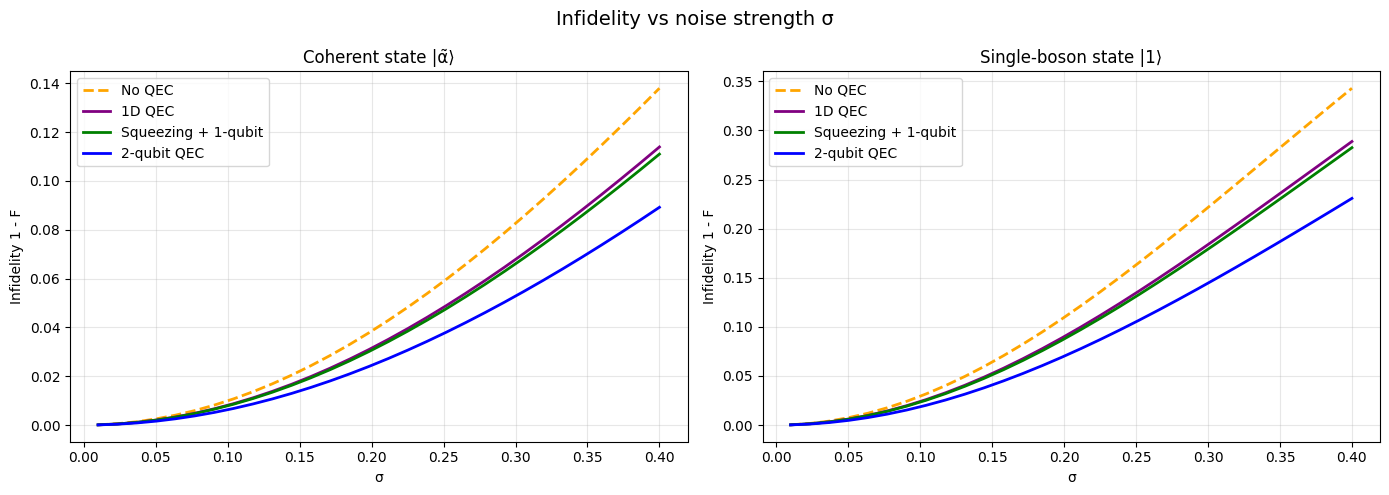

In [4]:
# Infidelity vs sigma for both states
sigmas = np.linspace(0.01, 0.4, 30)

# Storage
results = {
    'coherent':     {'no_qec': [], '1d': [], 'squeezing': [], '2qubit': []},
    'single_boson': {'no_qec': [], '1d': [], 'squeezing': [], '2qubit': []}
}

for sigma in sigmas:
    for state, f_func in [('coherent', f_coherent), ('single_boson', f_single_boson)]:
        results[state]['no_qec'].append(1 - fidelity_no_qec(f_func, sigma))
        results[state]['1d'].append(1 - fidelity_with_qec(f_func, sigma, '1d'))
        results[state]['squeezing'].append(1 - fidelity_with_qec(f_func, sigma, 'squeezing'))
        results[state]['2qubit'].append(1 - fidelity_with_qec(f_func, sigma, '2qubit'))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, state, title in zip(axes, 
                             ['coherent', 'single_boson'],
                             ['Coherent state |α̃⟩', 'Single-boson state |1⟩']):
    ax.plot(sigmas, results[state]['no_qec'],   color='orange', linestyle='--', linewidth=2, label='No QEC')
    ax.plot(sigmas, results[state]['1d'],        color='purple', linewidth=2, label='1D QEC')
    ax.plot(sigmas, results[state]['squeezing'], color='green',  linewidth=2, label='Squeezing + 1-qubit')
    ax.plot(sigmas, results[state]['2qubit'],    color='blue',   linewidth=2, label='2-qubit QEC')
    ax.set_xlabel('σ')
    ax.set_ylabel('Infidelity 1 - F')
    ax.set_title(title)
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle('Infidelity vs noise strength σ', fontsize=14)
plt.tight_layout()
plt.show()